# Is the drop real?

**Week 1, Tuesday. Notebook 1 of 5, round 1.** By the end of this notebook you can say whether
Kalpa's revenue fell between the two quarters, by how much, and on which windows, before anyone
explains why.

> **The client asks.** "So revenue is customers, times how often they buy, times basket, times
> price. Now: which of those moved? Q2 was Rs 1.9 crore, Q1 was 2.1. Are we losing customers, or
> are the ones we have buying less? Marketing says more customers. Prove it or disprove it."
>
> Meera Raghavan, CEO, Kalpa Retail

Monday drew the revenue tree on thirty orders from one window and ended on Anand's warning that one
large order can move an average. Today's export holds both quarters, 1 April to 30 September, and
the first rung of the ladder is to confirm that the drop exists on windows that match.

> **Kavya's review of Monday.** "You drew the tree before you opened the file. Keep doing that. Today
> the first thing I will ask is which dates sit on each side of your comparison."

**Setup.** The first lines walk up from this folder until they find the programme's helper,
`c2kit`, and import it as `kit`. Then the day's export loads as a list of dictionaries, one per
booked order, and `date` arrives so that a window can be measured in days.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from datetime import date, timedelta   # dates as calendar days, so a window can be measured

ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
print(len(ORDERS), "orders loaded")
print("fields:", ", ".join(ORDERS[0]))

200 orders loaded
fields: order_id, customer_id, segment, channel, city, order_date, amount, status, quarter, discount


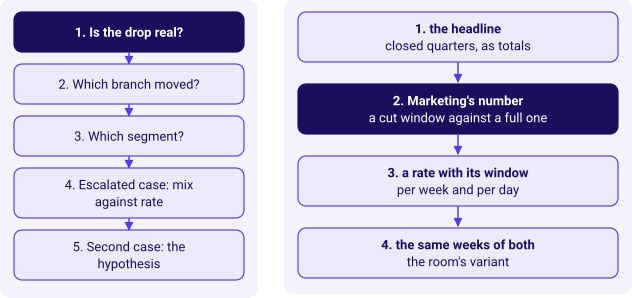

In [2]:
kit.side_by_side(
    kit.ladder(["Is the drop real?", "Which branch moved?", "Which segment?", "Escalated case: mix against rate", "Second case: the hypothesis"], lit=0, show=False),
    kit.vflow(["1. the headline\nclosed quarters, as totals",
               "2. Marketing's number\na cut window against a full one",
               "3. a rate with its window\nper week and per day",
               "4. the same weeks of both\nthe room's variant"], lit=1, show=False),
)

## 1. Revenue fell 11.0 percent between the two closed quarters

Both quarters have closed: Q1 ran 1 April to 30 June and Q2 ran 1 July to 30 September, thirteen
weeks each. A dictionary keyed by quarter collects revenue and orders in one pass, which is the
accumulator the rest of the day builds on: a key that is new starts at zero, and every order adds
to its own quarter's total.

**Predict before you run.** On the two closed quarters, how far did revenue move? a) it fell about
26 percent; b) it fell about 11 percent; c) it fell about 5 percent; d) it rose.

Quarter,Window,Orders,Revenue
Q1,"1 Apr to 30 Jun, 13 weeks",114,"Rs 2,10,00,000"
Q2,"1 Jul to 30 Sep, 13 weeks",86,"Rs 1,87,00,000"


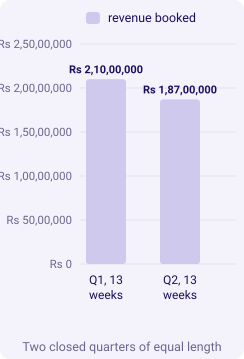

In [3]:
revenue = {}     # quarter -> rupees booked
orders = {}      # quarter -> number of orders
for order in ORDERS:
    q = order["quarter"]
    if q not in revenue:
        revenue[q] = 0
        orders[q] = 0
    revenue[q] += order["amount"]
    orders[q] += 1

change = (revenue["Q2"] - revenue["Q1"]) / revenue["Q1"] * 100
kit.table(["Quarter", "Window", "Orders", "Revenue"],
          [("Q1", "1 Apr to 30 Jun, 13 weeks", orders["Q1"], kit.rupees(revenue["Q1"])),
           ("Q2", "1 Jul to 30 Sep, 13 weeks", orders["Q2"], kit.rupees(revenue["Q2"]))],
          caption=f"Booked orders by quarter: revenue moved {change:.1f} percent")
kit.columns(["Q1, 13 weeks", "Q2, 13 weeks"], [("revenue booked", [revenue["Q1"], revenue["Q2"]])],
            fmt=kit.rupees, title="Two closed quarters of equal length")

**What happened.** The answer is b. Revenue fell from Rs 2,10,00,000 to Rs 1,87,00,000, which is
Rs 23,00,000 less and 11.0 percent down, on two windows of thirteen weeks. That is the number
Meera's question starts from, and it is smaller than the one in Marketing's deck.

In [4]:
kit.check("every order sits in one of the two quarters", orders["Q1"] + orders["Q2"] == len(ORDERS),
          f'{orders["Q1"]} + {orders["Q2"]} = {len(ORDERS)}')
kit.check("the closed-quarter change rounds to minus 11.0 percent", round(change, 1) == -11.0,
          f"{change:.2f}")
kit.check("the fall is Rs 23,00,000", revenue["Q1"] - revenue["Q2"] == 2300000,
          kit.rupees(revenue["Q1"] - revenue["Q2"]))

## 2. Marketing's 25.9 percent compares eleven weeks with thirteen

Marketing's deck reads the Q2 figure from the dashboard tile, which somebody screenshotted on
15 September, and sets it against the whole of Q1.

**Predict before you run.** Marketing's slide says revenue fell by about a quarter. What do you
check first? a) the segment mix of each quarter; b) the median order in each quarter; c) the first
and last date inside each window; d) whether discounts changed.

**The plausible wrong answer.** A hurried analyst takes the tile's number as Q2 and divides.

In [5]:
TILE_CUT = "2026-09-15"     # the day the dashboard tile was read

tile_revenue = 0
tile_orders = 0
for order in ORDERS:
    if order["quarter"] == "Q2" and order["order_date"] <= TILE_CUT:
        tile_revenue += order["amount"]
        tile_orders += 1

wrong = (tile_revenue - revenue["Q1"]) / revenue["Q1"] * 100
kit.stats([(kit.rupees(tile_revenue), "Q2 on the tile", f"{tile_orders} orders to 15 September"),
           (kit.rupees(revenue["Q1"]), "Q1, whole quarter", f'{orders["Q1"]} orders'),
           (f"{wrong:.1f}%", "Marketing's change", "the tile against the whole of Q1")])

**Why it is wrong.** The answer to the prediction is c. The tile stopped on 15 September, so its
window holds eleven weeks of trading, and it is being compared with thirteen. Two weeks of Q2 that
nobody had counted yet show up as lost revenue. Read as a crisis, a 25.9 percent fall pushes Meera
to release the Rs 12 crore acquisition budget in a hurry, on a gap that is mostly the calendar.

The check is to print, for each window, where it starts and ends, the first and last order inside
it, and the weeks it covers.

In [6]:
windows = {
    "Q1, whole quarter": (date(2026, 4, 1), date(2026, 6, 30), "Q1"),
    "Q2 on the tile":    (date(2026, 7, 1), date(2026, 9, 15), "Q2"),
    "Q2, whole quarter": (date(2026, 7, 1), date(2026, 9, 30), "Q2"),
}
first, last = {}, {}
for name in windows:
    start, end, q = windows[name]
    for order in ORDERS:
        d = date.fromisoformat(order["order_date"])
        if order["quarter"] == q and start <= d <= end:
            if name not in first or d < first[name]:
                first[name] = d
            if name not in last or d > last[name]:
                last[name] = d

days = {}
rows = []
for name in windows:
    start, end, q = windows[name]
    days[name] = (end - start).days + 1
    rows.append((name, f"{start:%d %b} to {end:%d %b}", f"{first[name]:%d %b}", f"{last[name]:%d %b}",
                 days[name], days[name] // 7))
kit.table(["Window", "Covers", "First order", "Last order", "Days", "Whole weeks"], rows,
          caption="The check: where each side of the comparison starts and stops")

Window,Covers,First order,Last order,Days,Whole weeks
"Q1, whole quarter",01 Apr to 30 Jun,01 Apr,27 Jun,91,13
Q2 on the tile,01 Jul to 15 Sep,02 Jul,15 Sep,77,11
"Q2, whole quarter",01 Jul to 30 Sep,02 Jul,28 Sep,92,13


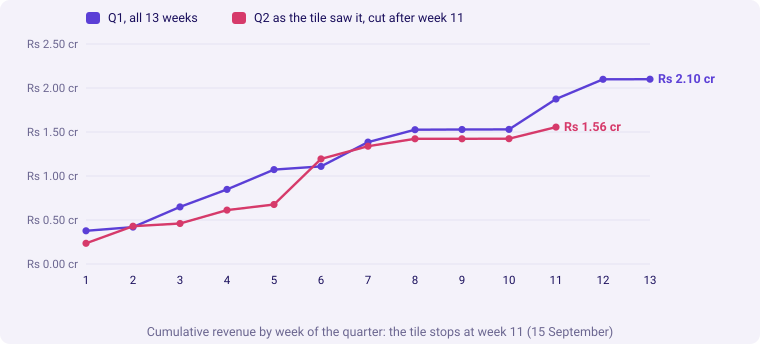

In [7]:
start = {"Q1": date(2026, 4, 1), "Q2": date(2026, 7, 1)}
weekly = {"Q1": [0] * 13, "Q2": [0] * 13}      # revenue by week of the quarter
for order in ORDERS:
    q = order["quarter"]
    week = (date.fromisoformat(order["order_date"]) - start[q]).days // 7   # 0 to 12
    weekly[q][min(week, 12)] += order["amount"]

cumulative = {"Q1": [], "Q2": []}
for q in cumulative:
    running = 0
    for amount in weekly[q]:
        running += amount
        cumulative[q].append(running)
tile_line = cumulative["Q2"][:11] + [None, None]

kit.line([str(w) for w in range(1, 14)],
         [("Q1, all 13 weeks", cumulative["Q1"], "plain"),
          ("Q2 as the tile saw it, cut after week 11", tile_line, "bad")],
         fmt=lambda v: f"Rs {v / 1e7:.2f} cr",
         title="Cumulative revenue by week of the quarter: the tile stops at week 11 (15 September)")

In [8]:
kit.check("Q1 covers 13 whole weeks", days["Q1, whole quarter"] // 7 == 13, f'{days["Q1, whole quarter"]} days')
kit.check("the tile covers 11 whole weeks", days["Q2 on the tile"] // 7 == 11, f'{days["Q2 on the tile"]} days')
kit.check("the tile's line ends where the tile total does", tile_line[10] == tile_revenue,
          kit.rupees(tile_line[10]))
kit.check("Marketing's figure rounds to minus 25.9 percent", round(wrong, 1) == -25.9, f"{wrong:.2f}")

**The fix.** Compare the closed quarters, thirteen weeks each, which is minus 11.0 percent and
Rs 23,00,000. The bridge below shows where Marketing's extra fall went: Q2's last two weeks, which
the tile had not reached, carried Rs 31,40,050 of revenue.

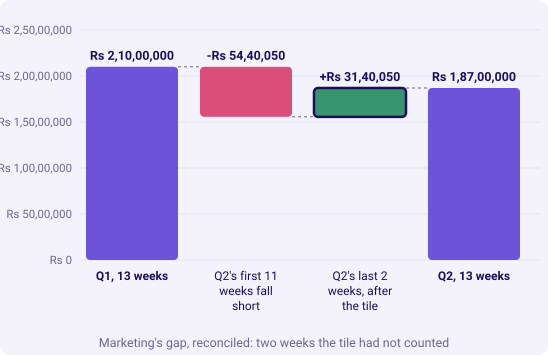

In [9]:
late = revenue["Q2"] - tile_revenue
kit.bridge(("Q1, 13 weeks", revenue["Q1"]),
           [("Q2's first 11 weeks fall short", tile_revenue - revenue["Q1"]),
            ("Q2's last 2 weeks, after the tile", late)],
           end_label="Q2, 13 weeks", lit=[1],
           title="Marketing's gap, reconciled: two weeks the tile had not counted")
kit.check("the bridge lands on the closed Q2 total", revenue["Q1"] + (tile_revenue - revenue["Q1"]) + late == revenue["Q2"],
          kit.rupees(revenue["Q2"]))
kit.check("the uncounted weeks hold 16 orders and Rs 31,40,050", (orders["Q2"] - tile_orders, late) == (16, 3140050),
          f'{orders["Q2"] - tile_orders} orders, {kit.rupees(late)}')

**What changed.** The fall Meera is asked to act on shrank from Rs 54,40,050 to Rs 23,00,000, and
from 25.9 percent to 11.0 percent. Sixteen orders worth Rs 31,40,050 were never missing; they had
not happened yet when the tile was read.

> **Kavya's review.** "Marketing's arithmetic was correct on a quarter that had not finished. Say
> both windows out loud with their first and last dates before you say a percentage. If they do
> not match, nothing you say after that counts."

## 3. A rate carries its numerator, its denominator and its window

Sometimes the later quarter is still open and a comparison cannot wait. A rate per week puts
windows of different length on one scale, provided the rate says what was counted, what it was
divided by, and over which dates.

**Predict before you run.** Revenue per week, Q1's thirteen weeks against the tile's eleven: how
far apart are they? a) minus 25.9 percent, the same as the totals; b) minus 12.4 percent;
c) no change; d) plus 5 percent.

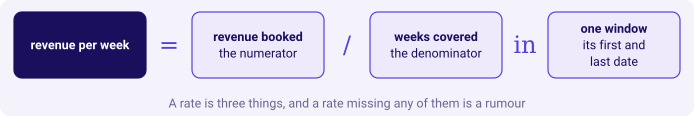

Rate,Numerator,Denominator,Window,Value
Q1 revenue per week,"Rs 2,10,00,000",13 weeks,1 Apr to 30 Jun,"Rs 16,15,385"
"Q2 revenue per week, tile","Rs 1,55,59,950",11 weeks,1 Jul to 15 Sep,"Rs 14,14,541"
Q1 revenue per day,"Rs 2,10,00,000",91 days,1 Apr to 30 Jun,"Rs 2,30,769"
Q2 revenue per day,"Rs 1,87,00,000",92 days,1 Jul to 30 Sep,"Rs 2,03,261"


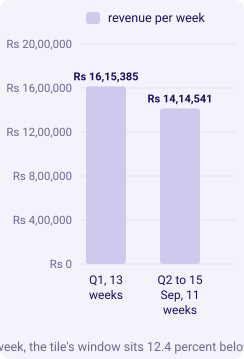

In [10]:
per_week_q1 = revenue["Q1"] / 13
per_week_tile = tile_revenue / 11
per_week_change = (per_week_tile - per_week_q1) / per_week_q1 * 100

per_day_q1 = revenue["Q1"] / days["Q1, whole quarter"]
per_day_q2 = revenue["Q2"] / days["Q2, whole quarter"]
per_day_change = (per_day_q2 - per_day_q1) / per_day_q1 * 100

kit.equation(["revenue per week", "=", "revenue booked\nthe numerator", "/",
              "weeks covered\nthe denominator", "in", "one window\nits first and last date"],
             title="A rate is three things, and a rate missing any of them is a rumour")
kit.table(["Rate", "Numerator", "Denominator", "Window", "Value"],
          [("Q1 revenue per week", kit.rupees(revenue["Q1"]), "13 weeks", "1 Apr to 30 Jun", kit.rupees(round(per_week_q1))),
           ("Q2 revenue per week, tile", kit.rupees(tile_revenue), "11 weeks", "1 Jul to 15 Sep", kit.rupees(round(per_week_tile))),
           ("Q1 revenue per day", kit.rupees(revenue["Q1"]), f'{days["Q1, whole quarter"]} days', "1 Apr to 30 Jun", kit.rupees(round(per_day_q1))),
           ("Q2 revenue per day", kit.rupees(revenue["Q2"]), f'{days["Q2, whole quarter"]} days', "1 Jul to 30 Sep", kit.rupees(round(per_day_q2)))],
          caption=f"Per week on the cut window {per_week_change:.1f}%; per day on the closed quarters {per_day_change:.1f}%")
kit.columns(["Q1, 13 weeks", "Q2 to 15 Sep, 11 weeks"], [("revenue per week", [round(per_week_q1), round(per_week_tile)])],
            fmt=kit.rupees, title="Per week, the tile's window sits 12.4 percent below Q1")

**What happened.** The answer is b. Per week, the eleven weeks of the tile sit 12.4 percent below
Q1, at Rs 14,14,541 a week against Rs 16,15,385. On the closed quarters, per day, the fall is
11.9 percent, because Q2 has 92 days and Q1 has 91. Every one of those figures is honest because
it says what it divided and over which dates, and none of them is 25.9 percent.

In [11]:
kit.check("revenue per week falls 12.4 percent on the cut window", round(per_week_change, 1) == -12.4,
          f"{per_week_change:.2f}")
kit.check("revenue per day falls 11.9 percent on the closed quarters", round(per_day_change, 1) == -11.9,
          f"{per_day_change:.2f}")
kit.check("Q2 has one day more than Q1", days["Q2, whole quarter"] - days["Q1, whole quarter"] == 1,
          f'{days["Q1, whole quarter"]} and {days["Q2, whole quarter"]}')

## 4. The same eleven weeks of both quarters give a different answer again

The room's variant: suppose Q2 were still open on 15 September. The like-with-like comparison is
then the first eleven weeks of each quarter, 1 April to 16 June against 1 July to 15 September.

**Predict before you run.** Q1's first eleven weeks against Q2's first eleven weeks: a) minus
12.4 percent, the same as the per-week rate; b) minus 11.0 percent, the same as the closed
quarters; c) a fall larger than both; d) a rise.

Window,Orders,Revenue
"Q1, 1 Apr to 16 Jun",97,"Rs 1,87,51,440"
"Q2, 1 Jul to 15 Sep",70,"Rs 1,55,59,950"


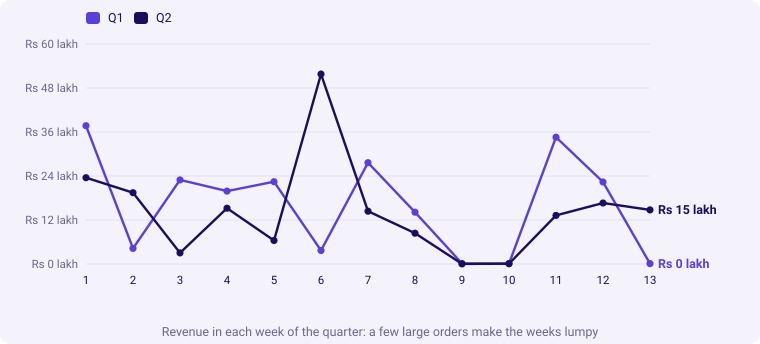

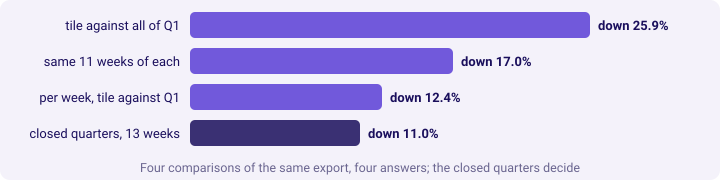

In [12]:
q1_cut = start["Q1"] + timedelta(days=76)      # the last day of Q1's eleventh week
same_revenue = 0
same_orders = 0
for order in ORDERS:
    if order["quarter"] == "Q1" and date.fromisoformat(order["order_date"]) <= q1_cut:
        same_revenue += order["amount"]
        same_orders += 1
same_change = (tile_revenue - same_revenue) / same_revenue * 100

kit.table(["Window", "Orders", "Revenue"],
          [(f"Q1, 1 Apr to {q1_cut:%d %b}", same_orders, kit.rupees(same_revenue)),
           ("Q2, 1 Jul to 15 Sep", tile_orders, kit.rupees(tile_revenue))],
          caption=f"The same eleven weeks of each quarter: {same_change:.1f}%")
kit.line([str(w) for w in range(1, 14)],
         [("Q1", weekly["Q1"], "plain"), ("Q2", weekly["Q2"], "lit")],
         fmt=lambda v: f"Rs {v / 1e5:.0f} lakh",
         title="Revenue in each week of the quarter: a few large orders make the weeks lumpy")
kit.bars([("tile against all of Q1", round(-wrong, 1)),
          ("same 11 weeks of each", round(-same_change, 1)),
          ("per week, tile against Q1", round(-per_week_change, 1)),
          ("closed quarters, 13 weeks", round(-change, 1))],
         fmt=lambda v: f"down {v:.1f}%", lit=[3],
         title="Four comparisons of the same export, four answers; the closed quarters decide")

**What happened.** The answer is c. The same eleven weeks give minus 17.0 percent: Q1's first
eleven weeks booked Rs 1,87,51,440 over 97 orders. That differs from the per-week minus 12.4
because Kalpa's weekly revenue is lumpy. A week with no large business order books about ten or
fifteen thousand rupees, and a week with three of them books lakhs, so which weeks a cut happens to
include moves the answer. The rule that follows: once a quarter has closed, compare closed
quarters; a quarter-to-date comparison uses the same weeks of both quarters and says so.

In [13]:
kit.check("Q1's first eleven weeks end on 16 June", q1_cut == date(2026, 6, 16), f"{q1_cut}")
kit.check("the same-weeks comparison is minus 17.0 percent", round(same_change, 1) == -17.0, f"{same_change:.2f}")
kit.check("the weekly figures add back to each quarter's total",
          sum(weekly["Q1"]) == revenue["Q1"] and sum(weekly["Q2"]) == revenue["Q2"])

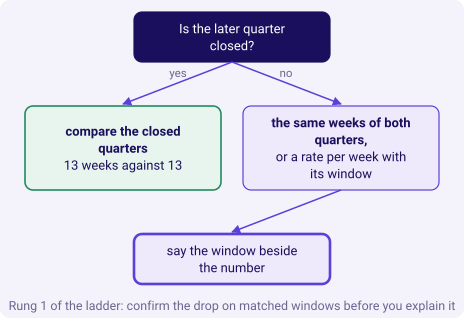

Comparison,Answer,Use it?
The tile against the whole of Q1,-25.9%,No: 11 weeks against 13
The same 11 weeks of each quarter,-17.0%,Only while Q2 is open
"Per week, the tile against Q1",-12.4%,Only with its window stated
The closed quarters,-11.0%,Yes: the number for Meera


In [14]:
kit.tree({"label": "Is the later quarter closed?", "kind": "lit", "branches": [
    ("yes", {"label": "compare the closed quarters\n13 weeks against 13", "kind": "good"}),
    ("no", {"label": "the same weeks of both quarters,\nor a rate per week with its window", "branches": [
        ("", {"label": "say the window beside the number", "kind": "known"})]})]},
    title="Rung 1 of the ladder: confirm the drop on matched windows before you explain it")
kit.table(["Comparison", "Answer", "Use it?"],
          [("The tile against the whole of Q1", f"{wrong:.1f}%", "No: 11 weeks against 13"),
           ("The same 11 weeks of each quarter", f"{same_change:.1f}%", "Only while Q2 is open"),
           ("Per week, the tile against Q1", f"{per_week_change:.1f}%", "Only with its window stated"),
           ("The closed quarters", f"{change:.1f}%", "Yes: the number for Meera")],
          caption="What round 1 established")

### In the interview

**[S] Sales dropped 15 percent last month; how would you investigate?** "In a fixed order. First I
confirm the drop is real: the same window on both sides, closed periods or the same days of each,
the same definition of a sale, and an export that is complete. Then I decompose revenue along a
tree, customers times orders per customer times revenue per order, and see which branch moved.
Then I split the moving branch by segment, and inside a segment I check whether a mix shift or a
real change in rate is behind it. Only then do I name a cause, as a hypothesis, with the evidence
that would settle it, and timing is the first test: a cause cannot come after its effect." The
interviewer is listening for the order, and above all for the first step, which most candidates
skip.

**[F] What has to match before a quarter-on-quarter comparison is fair?** "Five things. The window
length, and whether both periods have closed; if not, the same weeks of each, or a rate per week
with its window stated. The definition of the thing counted, booked or delivered. The population,
the same segments and the same customers in scope. The denominator behind any rate. And the export
itself: both sides pulled the same way, at a time when the later period was complete. Today's
example is a dashboard tile read on 15 September and set against a full quarter, which turned an
11.0 percent fall into 25.9." The interviewer is listening for window, definition, population and
denominator named without prompting.

### Depth: calendars that do not line up

Weeks and days are only the first level of matching. A quarter can hold one more weekend than
another, or a festival that falls in a different month from one year to the next, and a business
that trades mostly on weekends then shows a change that is only the calendar. The same test
applies: say what was divided by what, over which dates, and check whether the calendar alone
could produce the gap. Try it here: count the Saturdays and Sundays in each quarter with `date`
and `timedelta`, and decide whether Kalpa's gap could be a weekend effect.

References for the round:

- Brit Institute, data analyst case study questions, including "Sales dropped last month. How would you investigate?": https://britinstitute.uk/blog/data-analyst-case-study-interview-questions (verified 29 Sep 2026)
- Exponent, data analyst interview questions: https://www.tryexponent.com/blog/top-data-analyst-interview-questions (verified 29 Sep 2026)

In [15]:
kit.check_summary()
print("Next: notebook 2, which branch of the tree carries the Rs 23,00,000.")

Next: notebook 2, which branch of the tree carries the Rs 23,00,000.
